ques 1:Write a Python function called simple_generator() that takes a random vector as input and returns a 28x28 array of grayscale pixel values between 0 and 1, simulating a fake handwritten digit image like those used in GAN demos.

In [4]:
import numpy as np

def simple_generator(random_vector):
    # Ensure the input has enough values
    if len(random_vector) < 784:
        # Repeat values if the vector is too short
        random_vector = np.resize(random_vector, 784)
    else:
        # Take only the first 784 values
        random_vector = random_vector[:784]

    # Normalize values to the range [0, 1]
    min_val = np.min(random_vector)
    max_val = np.max(random_vector)

    if max_val != min_val:
        normalized = (random_vector - min_val) / (max_val - min_val)
    else:
        normalized = np.zeros(784)

    # Reshape into a 28x28 image
    fake_image = normalized.reshape(28, 28)

    return fake_image

In [5]:
# Example usage
random_input = np.random.randn(100)
generated_image = simple_generator(random_input)

print("Shape:", generated_image.shape)
print(generated_image)

Shape: (28, 28)
[[0.27895847 0.29233733 0.58091582 0.75900414 0.68210267 0.26915643
  0.64451849 0.50793966 0.61905177 0.45162502 0.50074005 0.69215172
  0.51405578 0.45418127 0.81432159 0.42815265 0.79439304 0.54120299
  0.64360788 0.66174923 0.63114071 0.79001245 0.44916855 0.42469136
  0.80032913 0.31600234 0.62594769 0.83597726]
 [0.34649313 0.64276896 0.43153311 0.55312461 0.36323233 0.50273557
  0.44469864 0.50196782 0.59719623 0.62043811 0.44975964 0.74761289
  0.34191312 0.7356459  0.47729345 0.69120523 0.63389095 0.5137791
  0.29584787 0.61300401 0.         0.90039352 0.44576145 0.12325563
  0.93287098 0.58770427 0.45750027 0.48897366]
 [0.45648288 0.66088308 0.80999266 0.87413305 0.43241413 0.73624475
  0.4503305  0.73694447 0.70816668 0.14777523 0.49693363 0.79249035
  0.50395444 0.64671333 0.48115125 0.43501166 0.64073188 0.57284558
  0.87616589 0.72170835 1.         0.49597721 0.41853201 0.56455149
  0.18661683 0.40500152 0.45689035 0.40185459]
 [0.63660499 0.58982331 0.56

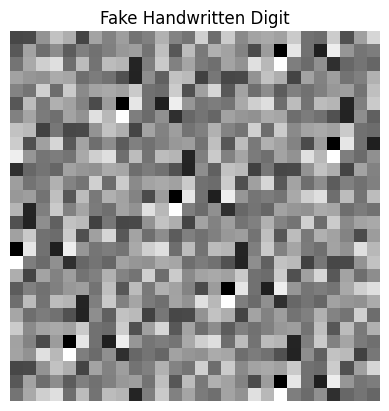

In [6]:
import matplotlib.pyplot as plt

plt.imshow(generated_image, cmap='gray')
plt.title("Fake Handwritten Digit")
plt.axis('off')
plt.show()

Ques2:Create a Python class Discriminator with a method discriminate(image) that takes a 28x28 image array and returns a probability score between 0 and 1 indicating if the image is 'real' or 'fake'.<br><br><em><strong>Hint:</strong> For this exercise, use a simple rule (e.g., mean pixel value threshold) instead of a neural network.</em>


In [7]:
import numpy as np

class Discriminator:
    def discriminate(self, image):
        """
        Determines whether a 28x28 image is 'real' or 'fake'
        based on its mean pixel value.

        Parameters:
        image (numpy array): 28x28 grayscale image.

        Returns:
        float: Probability score between 0 and 1.
        """
        # Check image size
        if image.shape != (28, 28):
            raise ValueError("Input image must be a 28x28 array.")

        # Calculate the mean pixel value
        mean_pixel = np.mean(image)

        # Simple probability rule
        # Higher mean -> more likely real
        probability = mean_pixel

        # Ensure the result is between 0 and 1
        probability = max(0, min(1, probability))

        return probability


# Example usage
image = np.random.rand(28, 28)  # Random grayscale image

disc = Discriminator()
score = disc.discriminate(image)

print("Probability that the image is real:", score)

Probability that the image is real: 0.4946171133957353


Simulate one cycle of the adversarial training loop: generate a fake image using your simple_generator(), get a score from your Discriminator, and print whether the Discriminator correctly identifies the fake image.


In [9]:
import numpy as np

# Generate a random input vector for the generator
random_input = np.random.randn(100)

# Generate fake image
fake_image = simple_generator(random_input)

# Create discriminator
D = Discriminator()

# Get prediction score
score = D.discriminate(fake_image)

print("Discriminator Score:", score)

if score < 0.5:
    print("Discriminator correctly identified the image as FAKE.")
else:
    print("Discriminator incorrectly classified the image as REAL.")

Discriminator Score: 0.5770123131055561
Discriminator incorrectly classified the image as REAL.


Ques 4: Research and list two real-world apps or features (outside of face generation) that use GANs for image-to-image translation, artistic style transfer, or deepfakes. For each, write one line on how GANs enable the feature.

1.  Prisma (Artistic Style Transfer)
GANs transform ordinary photos into artwork by learning and applying the style of famous paintings while preserving the original image content.
2.  NVIDIA Image-to-Image Translation (e.g., GauGAN)
GANs convert simple sketches or segmentation maps into realistic landscapes by generating detailed textures, lighting, and objects from user inputs.*italicised text*

ques 5: the difference between DCGAN, StyleGAN, and CycleGAN.

| Aspect              | DCGAN                                   | StyleGAN                                         | CycleGAN                              |
| ------------------- | --------------------------------------- | ------------------------------------------------ | ------------------------------------- |
| **Full Form**       | Deep Convolutional GAN                  | Style-based GAN                                  | Cycle-Consistent GAN                  |
| **Introduced**      | 2015                                    | 2018                                             | 2017                                  |
| **Primary Goal**    | Generate realistic images from noise    | Generate high-quality, controllable images       | Translate images between domains      |
| **Input**           | Random noise vector                     | Random noise + style vectors                     | An existing image                     |
| **Output**          | New synthetic image                     | High-resolution image with controllable features | Translated version of the input image |
| **Training Data**   | Single image domain                     | Single image domain                              | Two unpaired image domains            |
| **Main Innovation** | Convolutional layers                    | Style modulation and progressive generation      | Cycle consistency loss                |
| **Applications**    | Digit generation, basic image synthesis | Face generation, avatars, digital art            | Style transfer, object transformation |
